In [33]:
import re
import pickle
import stim
from autqec.automorphisms import *
from autqec.graph_auts import *
from autqec.utils.qec import *
from autqec.utils.qiskit import *
from autqec.magma_interface import *
from autqec.ZX_dualities import *
from autqec.ZY_dualities import *
# from encoded.expanded_repetition_code import stabilizer_generators, qs
from encoded.utils import cirq_pauli_string_to_stim

## From the tutorial

In [34]:
# Define code
n = 4
k = 2 
d = 2
stabs = ['XXXX','ZZZZ']
H_symp = stabs_to_H_symp(stabs)
H_3bit = np.hstack([H_symp,(H_symp[:,:n]+H_symp[:,n:])%2]) # adding XZ block 
H_3bit = np.vstack([H_3bit,(H_3bit[0,:]+H_3bit[1,:])%2]) # adding the YYYY stabilizer

In [35]:
print(H_symp)
print(H_3bit)

[[1 1 1 1 0 0 0 0]
 [0 0 0 0 1 1 1 1]]
[[1 1 1 1 0 0 0 0 1 1 1 1]
 [0 0 0 0 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 0 0 0 0]]


In [36]:
auts = valid_clifford_auts(H_3bit,bits_3=True) # computes graph auts that correspond to a physical Clifford operation

Order: 144


In [37]:
circuits = []
symp_mats = []
for num, aut in enumerate(auts):
    phys_act = circ_from_aut(H_symp,aut)        
    phys_circ, _ = phys_act.circ()
    log_act = logical_circ_and_pauli_correct(H_symp,phys_circ)
    circ = log_act.run()
    circuits.append(circ)
    symp_mats.append(log_act.U_logical_act())

Logical action: [('CZ', (1, 2))]


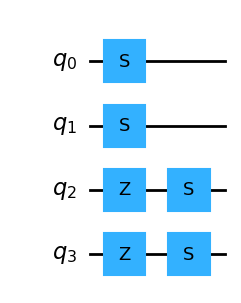

In [38]:
# example physical circuit and logical action
circ = circuits[0]
print('Logical action:',circ[0])
qc = construct_circuit(circ[1], n)
qc.draw(output='mpl')

## From `stim` to `autqec`

In [39]:
def stim_string_to_autqec_rep(pstring: stim.PauliString) -> str:
    """Converts a stim PauliString into a string recognized by autqec.
    '_' must be turned to 'I', and the phase is ignored."""

    ps_str = str(pstring)
    # Find the characters '_', 'I', 'X', 'Y', and 'Z'.
    prog = re.compile("[_IXYZ]+")
    result = prog.search(ps_str)
    if result is None:
        raise ValueError(f"{ps_str} does not represent a valid stim PauliString.")
    matching_str = result.string[result.span()[0]:result.span()[1]]
    return matching_str.replace("_", "I")

In [40]:
n = 3
k = 1
d = 3

stabilizer_generators = [
    stim.PauliString("ZZ_"), stim.PauliString("_ZZ")
]

stabilizer_strings = []
for stabilizer in stabilizer_generators:
    # stabilizer_stim = cirq_pauli_string_to_stim(stabilizer, qs)
    autqec_str = stim_string_to_autqec_rep(stabilizer)
    stabilizer_strings.append(autqec_str)

In [41]:
print("Check matrix:")
H_symp = stabs_to_H_symp(stabilizer_strings)
H_3bit = np.hstack([H_symp,(H_symp[:,:n]+H_symp[:,n:])%2])
print(H_symp)
print(H_3bit)

Check matrix:
[[0 0 0 1 1 0]
 [0 0 0 0 1 1]]
[[0 0 0 1 1 0 1 1 0]
 [0 0 0 0 1 1 0 1 1]]


In [42]:
auts = valid_clifford_auts(H_3bit, bits_3=True) # computes graph auts that correspond to a physical Clifford operation

Order: 16


In [43]:
circuits = []
symp_mats = []
for num, aut in enumerate(auts):
    phys_act = circ_from_aut(H_symp,aut)        
    phys_circ, _ = phys_act.circ()
    log_act = logical_circ_and_pauli_correct(H_symp,phys_circ)
    circ = log_act.run()
    circuits.append(circ)
    symp_mats.append(log_act.U_logical_act())

AssertionError: Physical circuit maps operators outside of code space.